In [1]:
# install libraries
import rioxarray
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# load and inspect data (one dataset)
data_2024 = rioxarray.open_rasterio("../data/LandsatComposite_Zurich_2024.tif")
data_2024

<xarray.DataArray (band: 7, y: 252, x: 297)> Size: 4MB
[523908 values with dtype=float64]
Coordinates:
  * band         (band) int64 56B 1 2 3 4 5 6 7
  * y            (y) float64 2kB 5.253e+06 5.253e+06 ... 5.245e+06 5.245e+06
  * x            (x) float64 2kB 4.6e+05 4.6e+05 4.6e+05 ... 4.688e+05 4.689e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'TIR1')

In [3]:
# create list of data to prepare for loop to extract mean values
files = [
    "../data/LandsatComposite_Zurich_1985.tif",
    "../data/LandsatComposite_Zurich_1988.tif",
    "../data/LandsatComposite_Zurich_1991.tif",
    "../data/LandsatComposite_Zurich_1994.tif",
    "../data/LandsatComposite_Zurich_1997.tif",
    "../data/LandsatComposite_Zurich_2000.tif",
    "../data/LandsatComposite_Zurich_2003.tif",
    "../data/LandsatComposite_Zurich_2006.tif",
    "../data/LandsatComposite_Zurich_2009.tif",
    "../data/LandsatComposite_Zurich_2012.tif",
    "../data/LandsatComposite_Zurich_2015.tif",
    "../data/LandsatComposite_Zurich_2018.tif",
    "../data/LandsatComposite_Zurich_2021.tif",
    "../data/LandsatComposite_Zurich_2024.tif"
]

years_list = [1985, 1988, 1991, 1994, 1997, 2000, 2003, 2006, 2009, 2012, 2015, 2018, 2021, 2024]

In [7]:
# Ceck NDVI values (Red and NIR)
for i in range(len(files)):
    data = rioxarray.open_rasterio(files[i])

    red = data.sel(band=3)
    nir = data.sel(band=4)

    print(years_list[i])

    print(f" red min {red.min()}")
    print(f"red max {red.max()}")

    print(f" nir min {nir.min()}")
    print(f" nir max {nir.max()}")

    #calculate ndvi
    ndvi = (nir - red) / (nir + red)

    print(f" ndvi min {ndvi.min()}")
    print(f" ndvi max {ndvi.max()}")


1985
 red min <xarray.DataArray ()> Size: 8B
array(0.0195875)
Coordinates:
    band         int64 8B 3
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'TIR1')
red max <xarray.DataArray ()> Size: 8B
array(0.2955225)
Coordinates:
    band         int64 8B 3
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'TIR1')
 nir min <xarray.DataArray ()> Size: 8B
array(0.03045)
Coordinates:
    band         int64 8B 4
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'TIR1')
 nir max <xarray.DataArray ()> Size: 8B
array(0.54987)
Coordinates:
    band         int64 8B 4
    spatial_ref  int64 8B 0
Attribu

In [15]:
#check TIR1
for i in range(len(files)):
    data = rioxarray.open_rasterio(files[i])
    lst = data.sel(band=7)
    print(f" tir1 min: {lst.min()}")
    print(f" tir1 max: {lst.max()}")

 tir1 min: <xarray.DataArray ()> Size: 8B
array(292.03217393)
Coordinates:
    band         int64 8B 7
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'TIR1')
 tir1 max: <xarray.DataArray ()> Size: 8B
array(318.88584806)
Coordinates:
    band         int64 8B 7
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'TIR1')
 tir1 min: <xarray.DataArray ()> Size: 8B
array(289.38149942)
Coordinates:
    band         int64 8B 7
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'TIR1')
 tir1 max: <xarray.DataArray ()> Size: 8B
array(317.93905652)
Coordinates:
    band         int64 8B 7
    spatial_ref

In [9]:
# for loop to extract overall mean values of each dataset
# create empty lists
years = []
mean_ndvi = []
mean_lst = []

# for-loop to select needed bands
for i in range(len(files)):
    data = rioxarray.open_rasterio(files[i])

    red = data.sel(band=3)
    nir = data.sel(band=4)
    lst = data.sel(band=7)

    red = red.where(red >= 0)
    nir = nir.where(nir >= 0)

    ndvi = (nir - red) / (nir + red)
    #double filter
    ndvi = ndvi.where((ndvi >= -1) & (ndvi <= 1))
    
    #check
    #print(f" ndvi min {ndvi.min()}")
    #print(f" ndvi max {ndvi.max()}")

    years.append(years_list[i])
    mean_ndvi.append(float(ndvi.mean()))
    mean_lst.append(float(lst.mean()))

    

In [10]:
# crate DataFrame
df = pd.DataFrame({
    "year" : years,
    "mean_ndvi" : mean_ndvi,
    "mean_lst" : mean_lst})
df

,year,mean_ndvi,mean_lst
0,1985,0.533143,301.934973
1,1988,0.525846,300.331244
2,1991,0.529560,301.846384
3,1994,0.540872,303.755825
4,1997,0.551348,300.666913
5,2000,0.565572,305.030489
6,2003,0.534408,305.352501
7,2006,0.541808,306.923132
8,2009,0.561700,305.349611
9,2012,0.555824,306.148102


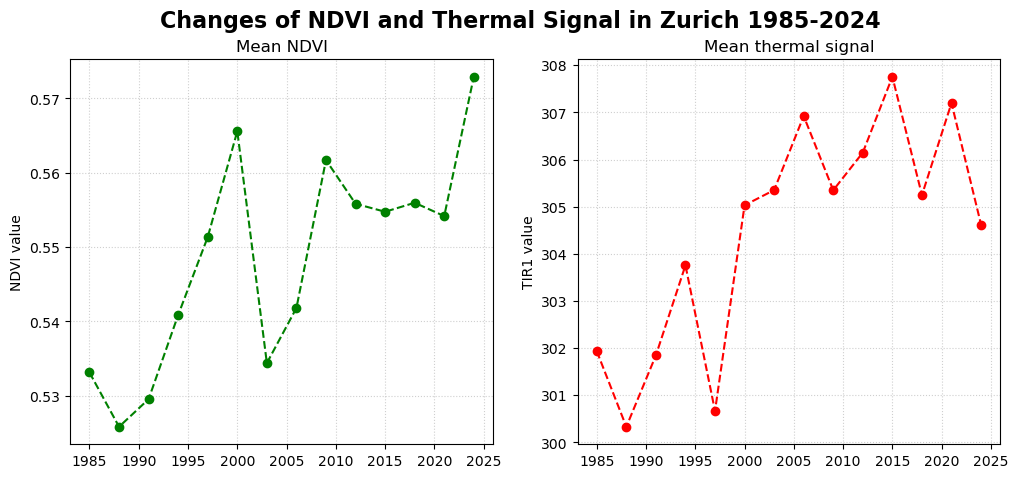

In [11]:
# subplot
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

axs[0].plot(df.year, df.mean_ndvi, color="green", marker="o", linestyle="--")
axs[1].plot(df.year, df.mean_lst, color="red", marker="o", linestyle="--")

axs[0].set_title("Mean NDVI")
axs[0].set_ylabel("NDVI value")
axs[0].grid(True, linestyle=":", alpha=0.6)

axs[1].set_title("Mean thermal signal")
axs[1].grid(True, linestyle=":", alpha=0.6)
axs[1].set_ylabel("TIR1 value")

fig.suptitle(
    "Changes of NDVI and Thermal Signal in Zurich 1985-2024", fontsize=16, fontweight="bold"
)

plt.show()

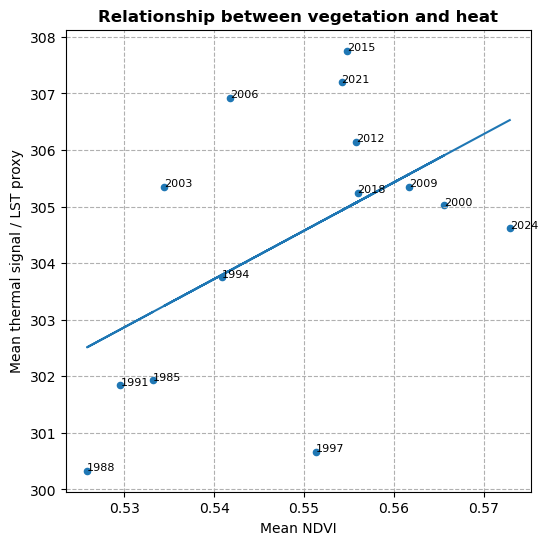

In [14]:
df.plot.scatter(
    x="mean_ndvi",
    y="mean_lst",
    figsize=(6,6)
)

for i in range(len(df)):
    plt.text(
        df["mean_ndvi"][i],
        df["mean_lst"][i],
        df["year"][i],
        fontsize=8
    )

z = np.polyfit(df["mean_ndvi"], df["mean_lst"], 1)
p = np.poly1d(z)

plt.plot(
    df["mean_ndvi"],
    p(df["mean_ndvi"])
)


plt.title("Relationship between vegetation and heat", fontsize=12, fontweight="bold")
plt.xlabel("Mean NDVI")
plt.ylabel("Mean thermal signal / LST proxy")
plt.grid(linestyle="--")

plt.show()